# Notebook example

In order to use this notebook, you need to install the HOD code at _https://github.com/jcallesh/HOD_. Normally, you would just use the command `pip install git+https://github.com/jcallesh/HOD.git`. However, this doesn't work for us because as it is written in that Github repository, that package relies on the deprecated _sklearn_, and we need to instead use _scikit-learn_.

In order to do this, I had to clone the aforementioned repository to create a local version of the repository. I then modified _setup.py_ in this local repository to use _scikit-learn_ instead of _sklearn_. However, before we can install the _pyhod_ package from this local repository, we have to set up a virtual environment to install the package into. To do this, we go to the NERSC terminal and put it into in a pre-set Python environment (with stuff like pip and conda pre-installed) - `module load python`

We then use _conda_ to create a new virtual environment that we can configure to our exact needs for the HOD code (by downloading the HOD package here then running the notebook out of this environment) - `conda create -n env_name python=3.11`. Note that we use Python version 3.11 because that was the latest version as of 2023 when the _pyhod_ code was first created. We enter the virtual environment with `conda activate env\_name` and use conda to install pip to that environment with `conda install pip`. 

We now navigate into the directory with the cloned HOD repository and install all the contents of the directory as a package to the virtual environment with `pip install .`. The final step is to make our new virtual environment a viable kernel from which we can run a jupyter notebook. We do this by first installing _ipykernel_ with `pip install ipykernel` and then we use the command `python -m ipykernel install --user --name=myenv`

There is a good chance you will also have to install _h5py_, _hdf5plugin_, _Pylians_ into your virtual environment on the command line with `pip install h5py`, `pip install hdf5plugin`, and `pip install Pylians`. I had trouble importing Pylians, so I might need to create a virtual environment with an older version of Python. However, it also might just be best for me to throw in the towel and just use a different HOD code. I sepnt a lot of time today reminding myself of virtual environment stuff and learning a lot more, but it might not even be worth trying to figure this out. I will find something else maybe.

In [19]:
# Load basic libraries from pyhod
import numpy as np
import sys
import os
import pyhod.hodfunc as hf
import pyhod.utils as utils
import psutil

#pyHOD contains a library to help read different halo catalogs such as Quijote Halos or EoS Halo catalogs.
import pyhod.read as read

# To facilitate the usage of the functions on pyHOD we set the relevant parameters in the config.py module as a dictionary.
# Make sure that "config.py" is in your working directory
import config

In [25]:
## Function to disable print
def blockPrint():
    # sys.stdout = open(os.devnull, 'w') # write out to dummy file
    sys.stdout = open('gal_cat_log.txt', 'w') # write to a text file for logging

## Function to restore print
def enablePrint():
    sys.stdout = sys.__stdout__

In the following cells, we choose random values for all HOD parameters. The random values are selected based on a uniform distribution across these prior ranges:
- log$M_{min}$ and log$M_0$ (aka $M_{cut}$), the minimum mass for a halo to host a central galaxy and the cut-off mass for halos to host any satellites: **[10.0, 13.7]**
- log$M_1'$ (aka $M_{sat}$), characteristic mass for a halo to host one satellite (also describes amplitude of how number of satellites grows with mass): **[13.8, 14.5]**
- $\alpha$, the power law dependence of number of satellites on mass: **[0.2, 1.8]**
- $\sigma_{logM}$, the scatter in the number of central galaxies with mass (how steep the transition is between 0 and 1 central galaxy at $M_{min}$): **[0.05, 0.6]**
- vel_bias, the velocities of satellite galaxies are picked from a normal distribution centered at the central galaxy velocity with standard deviation given by the Virial velocity of the halo. vel_bias is the factor by which this virial velocity is multiplied to get the standard deviation of galaxy velocities: **[0.2, 2.0]**


In [12]:
params = config.input_params_nb()
params['cat'] = 'Quijote_Halo'
params['method'] = 'NFW'
params['iRSD'] = 3

In [9]:
blockPrint()
num_halo_cat = 10000
for i in range(num_halo_cat):    
    # For each Quijote halo catalog, set all HOD params to some random value within the respective prior range
    params['ifile'] = f"/pscratch/sd/a/ajtorres/Quijote_Halos_Fiducial/{i}"
    params['outfile'] = f"Marginalized_Galaxy_Catalogs/{params['cat']}_Fid_HOD0_{params['method']}_1Gpc_z0.5_run{i}.npz"
    M = np.random.uniform(10.0, 13.7)
    params['logMmin'] = M
    params['logM0'] = M
    params['alpha'] = np.random.uniform(0.2, 1.8)
    params['logM1'] = np.random.uniform(13.8, 14.5)
    params['sigmalogM'] = np.random.uniform(0.05, 0.6)
    params['seed'] = np.random.randint(0, 10**6)
    params['vel_bias'] = np.random.uniform(0.2, 2.0)

    # Read in DM halo catalog
    data = read.readcats(params = params)

    # COMPUTE MEAN NUMBER OF GALAXIES
    HOD_param = params['logMmin'], params['sigmalogM'], params['logM0'], params['alpha'], params['logM1']
    centrals, satellites = hf.cent_sat(data,*HOD_param, params = params)

    # Assign positions and velocities for satellite galaxies using NFW
    galaxy_pos, galaxy_vel, galaxy_type, halo_group = hf.sample_catalog(data, centrals, satellites, params['vel_bias'], params = params)

    # Implement RSD along the z-axis of the galaxy catalog
    if params['iRSD'] > 0: 
        galaxy_pos = utils.displaceRSD(galaxy_pos, galaxy_vel, params)

    # Save the galaxy catalog
    output = params['outfile']
    print('\nNow Saving at:\n    --->OUTPUT FILE:%s\n'%output)
    np.savez_compressed(f"/pscratch/sd/a/ajtorres/{output}", pos=galaxy_pos, vel=galaxy_vel, gtype = galaxy_type)

In [107]:
# Check that random parameters are what you would expect
'''
# check all the input parameters 
for key,value in params.items():
    print(key, ' : ', value)
''';

# Visual Inspection

In [21]:
import matplotlib.pyplot as plt

In [22]:
enablePrint()
mycat = np.load(f"/pscratch/sd/a/ajtorres/{output}")
vec = np.array([mycat['pos'][:,0],mycat['pos'][:,1],mycat['pos'][:,2],mycat['gtype']]).T    
npart = len(vec[:,0])
print('Found %d galaxies.' %npart)
print('Number density: %.2e (h/Mpc)^3'%(npart/params['box']**3))

In [23]:
mask= (vec[:,2]>250)&(vec[:,2]<300)
pos_slice = vec[mask,:]

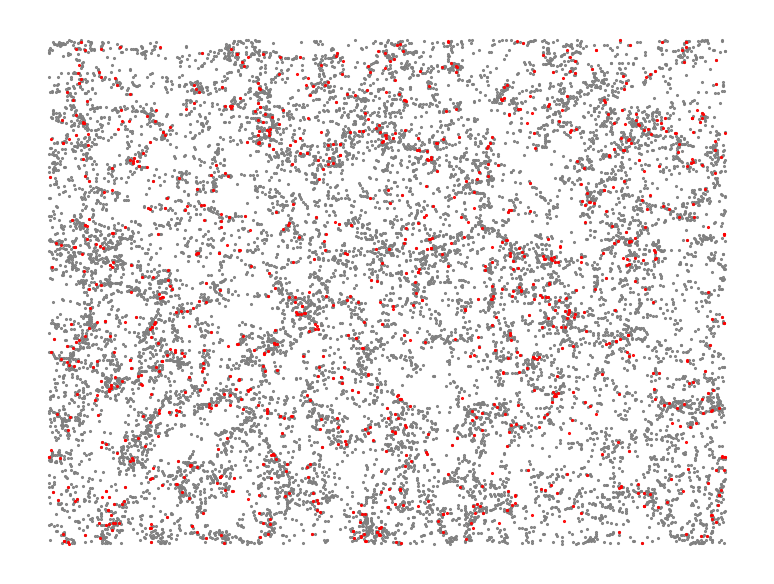

In [24]:
fig ,ax1 = plt.subplots(dpi=150)

# In the next two lines of uncommented code, we are effectively splitting the array 'pos_slice'
# into central and satellite galaxies. 'pos_slice[:,0:2]' extracts the xyz position coordinates
# for evert galaxy. [pos_slice[:-1].astype(bool)] then basically determines whether that galaxy
# is a central galaxy (True) or is a satellite galaxy (not False)
central = pos_slice[:,0:2][pos_slice[:,-1].astype(bool)]
satellites  = pos_slice[:,0:2][~pos_slice[:,-1].astype(bool)]

ax1.scatter(central[:,0],central[:,1],color='grey',s=0.25)
ax1.scatter(satellites[:,0],satellites[:,1],color='red',s=0.25)

plt.axis('off')
plt.show()